In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('/home/mingxuanzhang/PerturbVAE/PerturbVAE')

from model import *
from utils import *
from dataset import *
from train import *

In [2]:
data = sc.read_h5ad('/home/mingxuanzhang/PerturbVAE/PerturbVAE/data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [3]:
#sc.pp.normalize_total(data)
#sc.pp.log1p(data)
#sc.pp.pca(data)

#sc.pp.neighbors(data)
#sc.tl.umap(data)

In [4]:
#sc.pl.umap(data, color=['treatment', 'top_sg'], size=10)

In [5]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

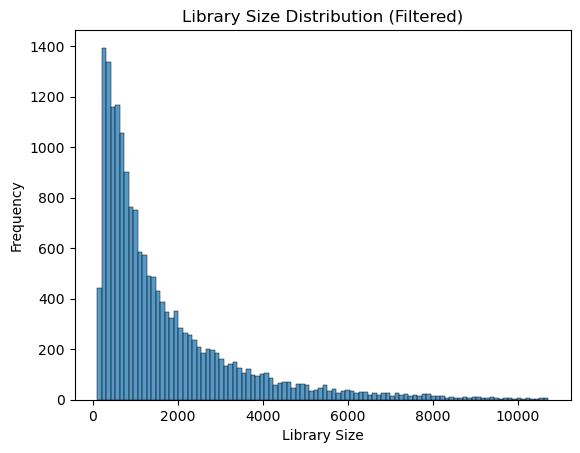

In [6]:
sns.histplot(data.obs['library_size'], bins=100)
plt.xlabel('Library Size')
plt.ylabel('Frequency')
plt.title('Library Size Distribution (Filtered)')
plt.show()

In [7]:
theta = torch.tensor([1.5])
mu = torch.tensor([2000])
EPS = 1e-6
logits = mu.log() - theta.log()

nb_dist = dist.NegativeBinomial(total_count=theta, logits=logits)

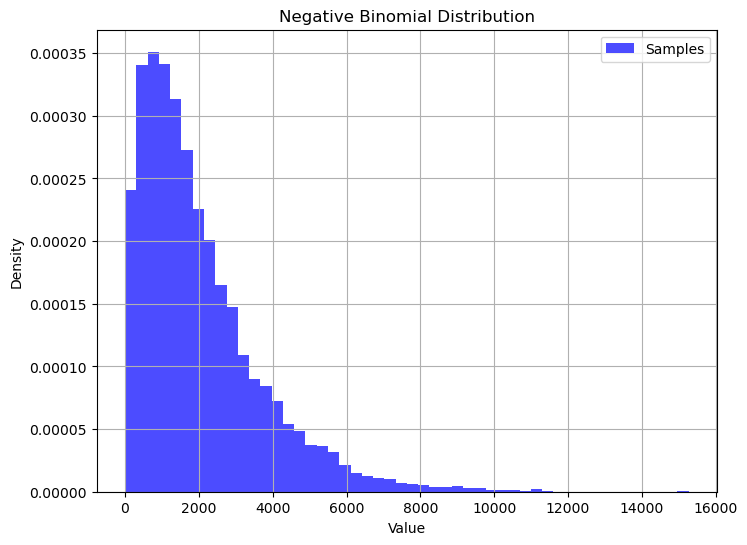

In [8]:
import matplotlib.pyplot as plt

# Sample from the negative binomial distribution
samples = nb_dist.sample((10000,))

# Plot the histogram of the samples
plt.figure(figsize=(8, 6))
plt.hist(samples.numpy(), bins=50, density=True, alpha=0.7, color='blue', label='Samples')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Negative Binomial Distribution')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
dataset = PerturbDataset(data)

In [10]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [11]:
%load_ext autoreload
%autoreload 2

In [12]:
# ----------------------------------------------------------------------
# 1. GLOBAL DEBUG SWITCHES
# ----------------------------------------------------------------------
import warnings, math, functools, inspect, builtins
import pyro, torch

torch.autograd.set_detect_anomaly(True)          # traces op that first returns NaN / Inf
pyro.enable_validation(True)                     # Pyro distributions raise on bad params

def _dbg(name, t):
    """Print shape/range + assert finite."""
    if isinstance(t, torch.Tensor):
        if not torch.isfinite(t).all():
            bad = t[~torch.isfinite(t)]
            print(f"[NaN‑DEBUG] {name} has {bad.numel()} non‑finite values. "
                  f"Min={bad.min().item() if bad.numel() else 'NA'} "
                  f"Max={bad.max().item() if bad.numel() else 'NA'} "
                  f"Example={bad.flatten()[0].item() if bad.numel() else 'NA'}")
            raise ValueError(f"NaN or Inf detected in {name}")
        else:
            # comment‑out next line if it is too chatty
            print(f"[OK] {name:15s}  shape={tuple(t.shape)} "
                  f"range=({t.min().item():.3g}, {t.max().item():.3g})")
    return t
# ----------------------------------------------------------------------


In [13]:
import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch

import pyro.distributions as dist
import torch.nn as nn
from tqdm import tqdm 
from sklearn.metrics import r2_score
from model_simple import VAE



# Initialize the VAE
pyro.clear_param_store()

input_dim = data.shape[-1] 
latent_dim = 16
vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 100, 5.0)
vae = vae.to(vae.device)

# Optimizer and SVI
optimizer = Adam({"lr": 5e-4})
svi = SVI(vae.model, vae.guide, optimizer, loss=Trace_ELBO())

# Example training loop
print("Training VAE...", vae.device)
num_epochs = 10
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    all_actuals = []
    all_predictions = []
    cls_loss = 0
    for X, P, C in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False):
        # Move data to the same device as the model
        X = X.to(vae.device).float()
        P = P.to(vae.device).int()
        C = C.to(vae.device).int()
        
        loss = svi.step(X, P, C)
        epoch_loss += loss
        losses.append(loss)
        
        with torch.no_grad(), poutine.trace() as tr:
            vae.model(X, P, C)         
        node = tr.trace.nodes.get("cls_p")
        cls_loss += node["fn"].log_factor[0]
        
        with torch.no_grad():
            z_loc, _ = vae.z_encoder(torch.cat([X,vae.p_emb(P)], dim=-1)).chunk(2, dim=-1)  # Latent space
            decoded_logits = vae.z_decoder(z_loc)               # Reconstructed data
            mu = torch.softmax(decoded_logits, dim=-1)
            total_counts = X.sum(-1, keepdim=True)
            x_mu = total_counts * mu

            all_actuals.append(X.cpu().numpy())
            all_predictions.append(x_mu.cpu().numpy())

    # Calculate R² at the end of the epoch
    all_actuals = np.concatenate(all_actuals, axis=0)
    all_predictions = np.concatenate(all_predictions, axis=0)
    r2 = r2_score(all_actuals.flatten(), all_predictions.flatten())

    print(f"Epoch {epoch + 1}, Loss: {epoch_loss / dataset.X.shape[0]:.4f}, R²: {r2:.4f}, Classification Loss: {cls_loss:.4f}")

Training VAE... cuda


Epoch 1, Loss: 2682.4556, R²: 0.5433, Classification Loss: -82829.2578


Epoch 2, Loss: 2480.7757, R²: 0.6429, Classification Loss: -83105.0156


Epoch 3, Loss: 2439.5876, R²: 0.6669, Classification Loss: -82804.8594


Epoch 4, Loss: 2412.1314, R²: 0.6810, Classification Loss: -95257.7969


...

Epoch 6, Loss: 2227.5851, R²: 0.6993, Classification Loss: -301943.5938


Epoch 7, Loss: 2116.6808, R²: 0.7030, Classification Loss: -490544.0312


Epoch 8, Loss: 2035.5747, R²: 0.7040, Classification Loss: -675277.3125


Epoch 9, Loss: 1960.8452, R²: 0.7066, Classification Loss: -845435.8750


Epoch 10, Loss: 1910.9030, R²: 0.7093, Classification Loss: -997263.9375


In [14]:
vae.total_counts.max()

7132.0

In [15]:
import pyro.poutine as poutine
model = vae
model.device = torch.device('cpu')
model.eval()
model = model.to(model.device)


X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

trace = poutine.trace(model.guide).get_trace(X, P, C)

In [16]:
model

VAE(
  (p_emb): Embedding(100, 16)
  (c_emb_mu): Embedding(4, 16)
  (c_emb_logvar): Embedding(4, 16)
  (z_encoder): Sequential(
    (0): Linear(in_features=2234, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=512, out_features=32, bias=True)
  )
  (z0_encoder): Sequential(
    (0): Linear(in_features=2234, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=512, out_features=32, bias=True)
  )
  (z_decoder): Sequential(
    (0): Linear(in_features=16, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=512, out_features=2218, bias=True)
  )
  (z_pr

In [17]:
z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

In [18]:
correct = 0
total   = 0

logits = model.z_prediction_head(z) 
y_pred = logits.argmax(dim=-1) 
correct += (y_pred == P).sum().item()
total   += P.size(0)

accuracy = correct / total
print(f"Classification accuracy: {accuracy:.4f}")

Classification accuracy: 0.8757


/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


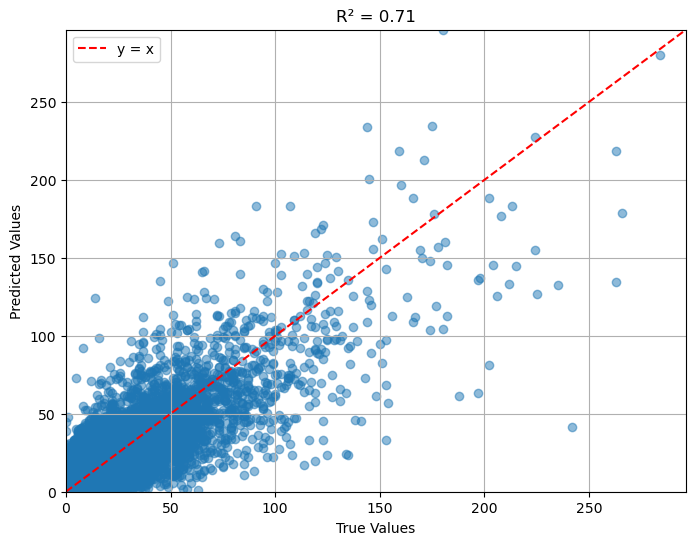

In [19]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(dataset.X.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, dataset.X.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = dataset.X[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


In [20]:
rho = trace.nodes["rho"]["value"]
print(rho.shape)
#rho_at_P = rho[batch_indices, P, :]  # shape: [batch, latent_dim]

#data.obsm['rho'] = rho_at_P.detach().cpu().numpy()


torch.Size([100, 16])


In [21]:
z = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

In [22]:
z_data = data.copy()
z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, use_rep='z', n_neighbors=15)
sc.tl.umap(z_data)

In [23]:
z0_data = data.copy()
z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='z0', n_neighbors=15)
sc.tl.umap(z0_data)

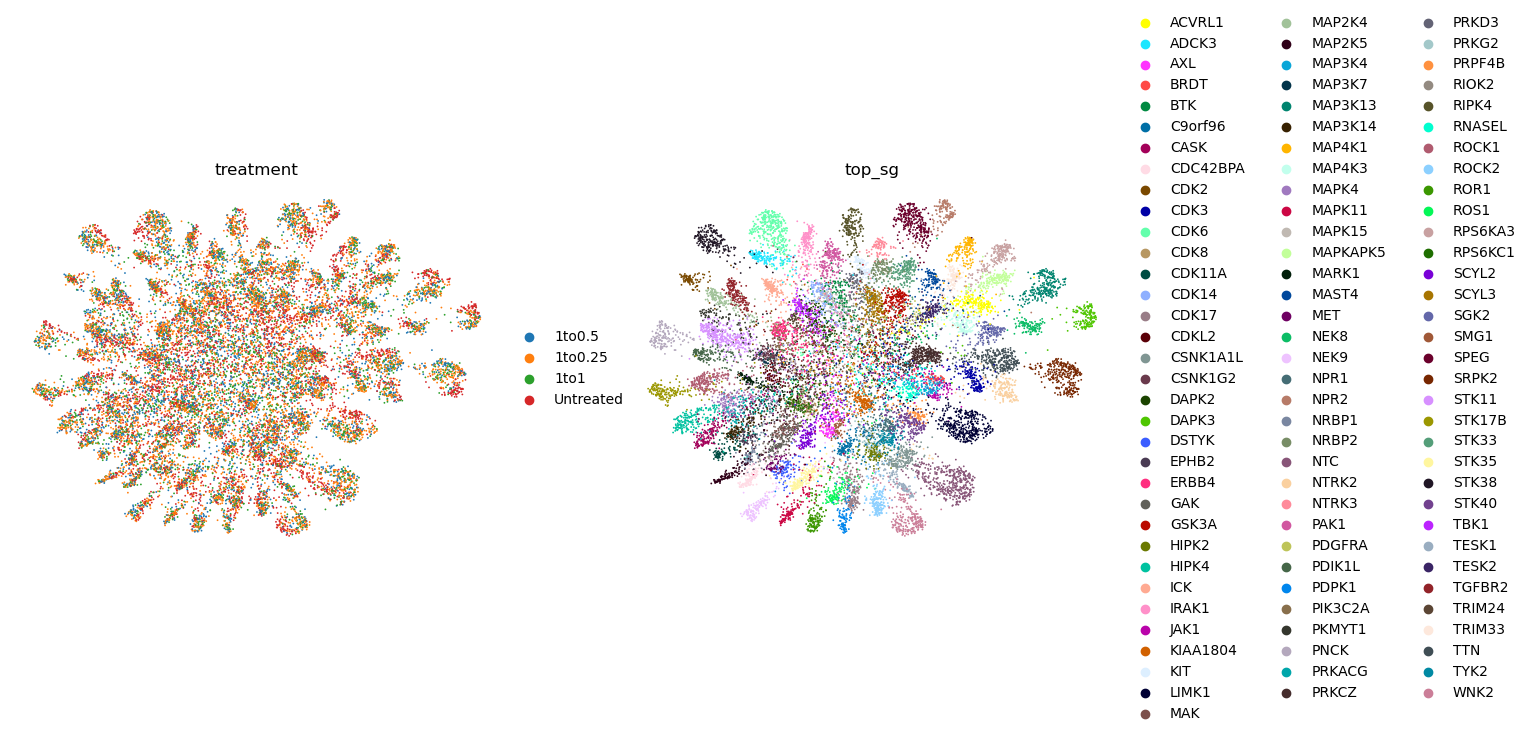

In [24]:
sc.pl.umap(z_data, color=['treatment', 'top_sg'], frameon=False, show=True)

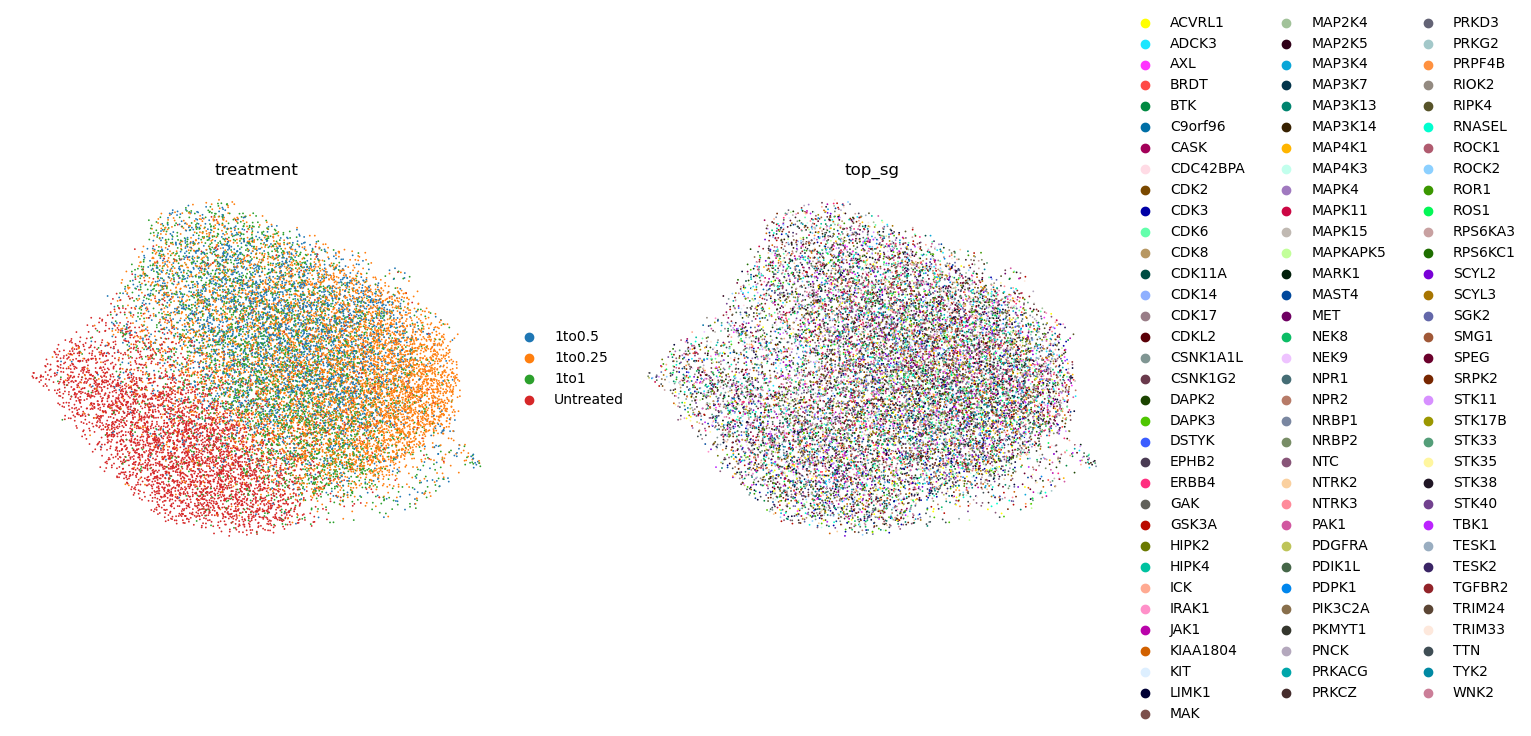

In [25]:
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

(array([ 9., 12., 19., 13., 17., 11., 17., 17., 18., 13., 18., 20., 19.,
        26., 21., 19., 21., 10., 19., 21., 20., 26.,  9.,  8., 23., 19.,
        10.,  8., 12., 17., 15., 16., 12., 20., 15., 15., 12., 20., 17.,
        14., 12., 18., 22., 19., 16., 11., 11.,  9., 18., 15., 10., 14.,
        11., 21., 16., 17., 15., 17., 16., 16., 23., 24., 10., 18., 11.,
        11., 13., 17., 16., 20., 11., 26., 13., 21., 13., 21., 12., 12.,
        15., 17., 16., 21., 23., 10., 17., 14., 13., 16., 18., 11., 17.,
        16., 16., 15., 13., 12., 18., 20., 13., 25.]),
 array([-2.27087811e-01, -2.22543865e-01, -2.17999905e-01, -2.13455960e-01,
        -2.08912015e-01, -2.04368055e-01, -1.99824110e-01, -1.95280164e-01,
        -1.90736219e-01, -1.86192259e-01, -1.81648314e-01, -1.77104369e-01,
        -1.72560409e-01, -1.68016464e-01, -1.63472518e-01, -1.58928558e-01,
        -1.54384613e-01, -1.49840668e-01, -1.45296708e-01, -1.40752763e-01,
        -1.36208817e-01, -1.31664857e-01, -1.27120912e

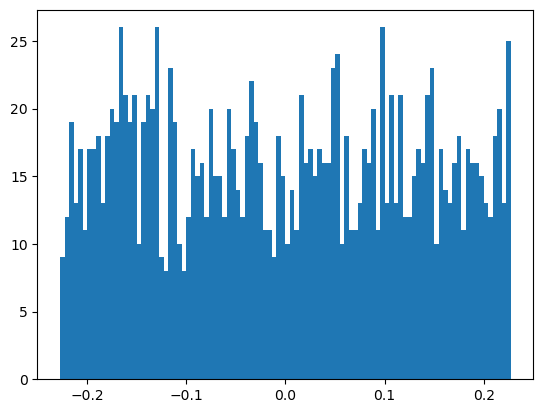

In [30]:
B = model.B.detach().cpu().numpy()
plt.hist(B.flatten(), bins=100)